# Attention Maps — ViT-RGTS Handwriting Recognition

Character-level attention visualization for a CTC-based Vision Transformer with Register Tokens.  
Two scientifically grounded methods:

1. **Gradient Saliency** — `|∂ logit(c,t) / ∂ x|` — true 2D pixel-level attribution  
2. **Self-Attention** — transformer attention weights at the CTC-peak token per character

In [1]:
import sys, json
from pathlib import Path
from types import SimpleNamespace
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, zoom

ROOT = Path('.').resolve()
if ROOT.name == 'notebook': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from models import HTRNet
from utils.preprocessing import load_image, preprocess

DEVICE = 'cpu'
H, W = 128, 1024
EXP = ROOT / 'saved_models' / 'experiments'
OUT = ROOT / 'outputs' / 'attention_maps'; OUT.mkdir(parents=True, exist_ok=True)
SAMPLES = ROOT / 'notebook' / 'sample_images'

charset = list(np.load(str(EXP / 'classes.npy'), allow_pickle=True))
MODELS = {0: 'run_76', 4: 'run_84', 8: 'run_63', 16: 'run_71'}
print(f'{len(charset)} classes  |  Device: {DEVICE}')

79 classes  |  Device: cpu


In [2]:
# ── Utility functions ──────────────────────────────────────────────

def load_model(run_id):
    cfg = json.load(open(EXP / run_id / 'config.json'))
    m = HTRNet(SimpleNamespace(**cfg['arch']), len(charset) + 1)
    m.load_state_dict(torch.load(str(EXP / run_id / 'model.pt'),
                                  map_location=DEVICE, weights_only=False), strict=False)
    return m.to(DEVICE).eval()

def prep(path):
    """Load image → preprocess → tensor.  Returns (tensor[1,1,H,W], numpy[H,W])."""
    img = preprocess(load_image(str(path)), (H, W))
    t = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).float().to(DEVICE)
    return t, img

def ctc_decode(logits):
    """Greedy CTC decode → (text, [(char, peak_t), ...])."""
    ids = logits[:, 0, :].softmax(-1).argmax(-1).cpu().numpy()
    out, prev = [], -1
    for t, idx in enumerate(ids):
        if idx != 0 and idx != prev:
            ci = idx - 1
            if 0 <= ci < len(charset):
                out.append((str(charset[ci]), t))
        prev = idx
    # Strip leading/trailing spaces
    while out and out[0][0] == ' ':  out.pop(0)
    while out and out[-1][0] == ' ': out.pop()
    text = ''.join(c for c, _ in out)
    return text, out

def crop(img, pad=8):
    """
    Tight-crop to ink bounding box.
    Images are INVERTED: 0 = white, high = ink.
    Returns (cropped, (y0, y1, x0, x1)).
    """
    cmean = img.mean(0); rmean = img.mean(1)
    cc = np.where(cmean > cmean.max() * 0.05)[0]
    rr = np.where(rmean > rmean.max() * 0.05)[0]
    if len(cc) == 0 or len(rr) == 0:
        return img, (0, img.shape[0], 0, img.shape[1])
    x0, x1 = max(0, cc[0]-pad), min(img.shape[1], cc[-1]+pad)
    y0, y1 = max(0, rr[0]-pad), min(img.shape[0], rr[-1]+pad)
    return img[y0:y1, x0:x1], (y0, y1, x0, x1)

print('Utilities loaded.')

Utilities loaded.


In [3]:
# ── Load one image & model, decode, crop ───────────────────────────
IMG = 'a01-038-12.png'   # GT: "talks."
RUN = 'run_63'           # 8 registers, best CER

model = load_model(RUN)
tensor, img_np = prep(SAMPLES / IMG)
img_c, (y0, y1, x0, x1) = crop(img_np)

with torch.no_grad():
    logits = model(tensor)
text, char_peaks = ctc_decode(logits)

R = model.backbone.num_registers
print(f'Image: {img_np.shape} → crop {img_c.shape}  ({100*(1-img_c.size/img_np.size):.0f}% removed)')
print(f'Decoded: "{text}"  |  Peaks: {char_peaks}  |  R={R}')

/home/hpc/iwi5/iwi5369h/HTR-Pipeline/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Image: (128, 1024) → crop (128, 168)  (84% removed)
Decoded: "talks."  |  Peaks: [('t', 3), ('a', 6), ('l', 9), ('k', 12), ('s', 16), ('.', 20)]  |  R=8


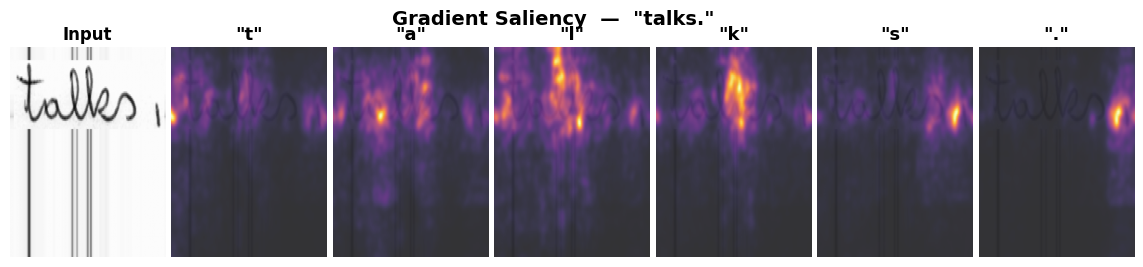

Saved fig5_grad_saliency.png


In [4]:
# ── 1. Gradient Saliency ──────────────────────────────────────────
#
# For each character c at CTC time-step t:
#   saliency = | ∂ logit[t, class(c)] / ∂ x |   (smoothed)
#
# This is the gold-standard input attribution: it directly measures
# each pixel's contribution to each character prediction.

sal_maps = []
for ch, t in char_peaks:
    inp = tensor.clone().requires_grad_(True)
    model.zero_grad()
    out = model(inp)
    out[t, 0, charset.index(ch) + 1].backward()
    g = inp.grad[0, 0].abs().cpu().numpy()
    g = gaussian_filter(g, sigma=2)[y0:y1, x0:x1]
    gmin, gmax = g.min(), g.max()
    sal_maps.append((g - gmin) / (gmax - gmin) if gmax > gmin else g * 0)

# ── Plot ──
n = len(char_peaks)
ar = img_c.shape[0] / img_c.shape[1]
cw = 2.0; ch_h = max(cw * ar, 0.9)

fig, axes = plt.subplots(1, n+1, figsize=(cw*(n+1)+0.5, ch_h+1.2))
axes[0].imshow(img_c, cmap='gray_r', aspect='auto'); axes[0].set_title('Input', fontweight='bold')
for i, ((c, _), s) in enumerate(zip(char_peaks, sal_maps)):
    ax = axes[i+1]
    ax.imshow(img_c, cmap='gray_r', aspect='auto', alpha=0.2)
    ax.imshow(s, cmap='inferno', aspect='auto', alpha=0.8, vmin=0, vmax=1)
    ax.set_title(f'"{c}"', fontsize=13, fontweight='bold')
for ax in axes: ax.axis('off')

fig.suptitle(f'Gradient Saliency  —  "{text}"', fontsize=14, fontweight='bold', y=1.02)
plt.subplots_adjust(wspace=0.04)
fig.savefig(str(OUT/'fig5_grad_saliency.png'), dpi=200, bbox_inches='tight')
fig.savefig(str(OUT/'fig5_grad_saliency.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig)
print('Saved fig5_grad_saliency.png')

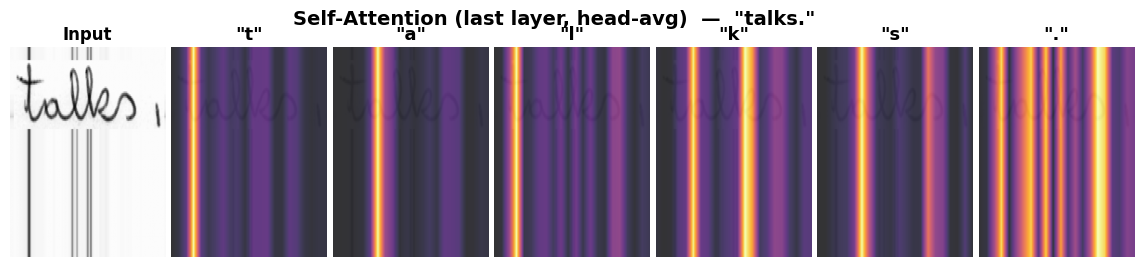

Saved fig5_self_attn.png


In [5]:
# ── 2. Self-Attention Maps ────────────────────────────────────────
#
# For each character c at CTC time-step t:
#   attn_map = A[R+t, R:]  from the last transformer layer
#   (averaged over heads, register tokens excluded from keys)
#
# This shows where the transformer "looks" for each character.
# The ViT uses 1D patch tokens (height collapsed by CNN stem),
# so attention is 1D along the width axis, broadcast vertically.

with torch.no_grad():
    _, _, attn_maps, _, (Hp, Wp) = model.forward_explain(tensor)

attn_last = attn_maps[-1][0].mean(0).numpy()   # [S, S] head-averaged
scale = W / Wp
pl, pr = max(0, int(x0/scale)), min(Wp, int(np.ceil(x1/scale)))

attn_1d = []
for ch, t in char_peaks:
    row = attn_last[R+t, R:][pl:pr]             # attention to visible patches
    rmin, rmax = row.min(), row.max()
    attn_1d.append((row - rmin)/(rmax - rmin) if rmax > rmin else row * 0)

# ── Plot ──
fig, axes = plt.subplots(1, n+1, figsize=(cw*(n+1)+0.5, ch_h+1.2))
axes[0].imshow(img_c, cmap='gray_r', aspect='auto'); axes[0].set_title('Input', fontweight='bold')
for i, ((c, _), a) in enumerate(zip(char_peaks, attn_1d)):
    ax = axes[i+1]
    a_up = zoom(a, img_c.shape[1]/len(a), order=1)[:img_c.shape[1]]
    a2d = np.tile(a_up, (img_c.shape[0], 1))
    ax.imshow(img_c, cmap='gray_r', aspect='auto', alpha=0.2)
    ax.imshow(a2d, cmap='inferno', aspect='auto', alpha=0.8, vmin=0, vmax=1)
    ax.set_title(f'"{c}"', fontsize=13, fontweight='bold')
for ax in axes: ax.axis('off')

fig.suptitle(f'Self-Attention (last layer, head-avg)  —  "{text}"', fontsize=14, fontweight='bold', y=1.02)
plt.subplots_adjust(wspace=0.04)
fig.savefig(str(OUT/'fig5_self_attn.png'), dpi=200, bbox_inches='tight')
fig.savefig(str(OUT/'fig5_self_attn.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig)
print('Saved fig5_self_attn.png')

/home/hpc/iwi5/iwi5369h/HTR-Pipeline/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


   0 reg → "talks."
   4 reg → "talks."
   8 reg → "talks."
  16 reg → "talks."


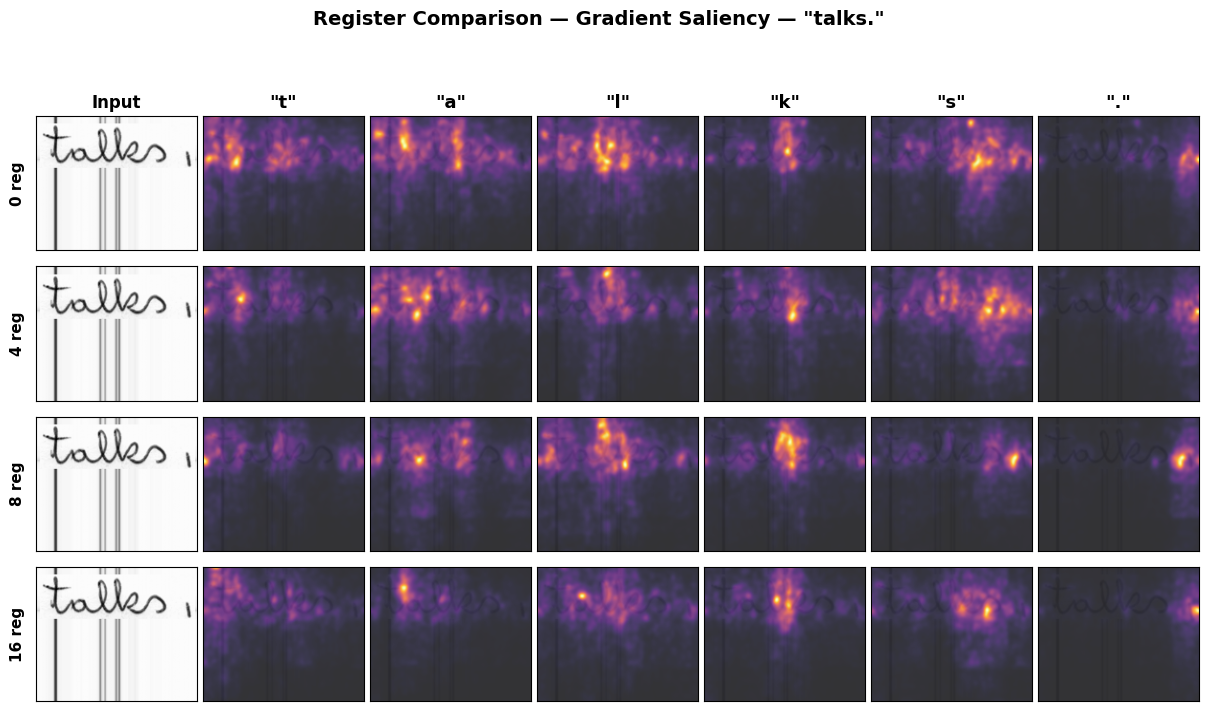

Saved fig5_register_comparison.png


In [6]:
# ── 3. Register Comparison (0 / 4 / 8 / 16) ──────────────────────
#
# Same image, same method (gradient saliency), different register counts.
# Rows = register configs, Columns = Input + per-character maps.
# This directly shows how register tokens affect attention quality.

del model  # free memory

reg_configs = sorted(MODELS.keys())
nrows = len(reg_configs)
# Use first model's decode as reference for column headers
ref_model = load_model(MODELS[reg_configs[0]])
with torch.no_grad(): ref_logits = ref_model(tensor)
ref_text, ref_peaks = ctc_decode(ref_logits)
del ref_model
ncols = len(ref_peaks) + 1

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(cw*ncols+1, ch_h*nrows+1.5))

for row, nr in enumerate(reg_configs):
    mdl = load_model(MODELS[nr])
    with torch.no_grad(): lg = mdl(tensor)
    txt, peaks = ctc_decode(lg)
    
    # Input column
    axes[row, 0].imshow(img_c, cmap='gray_r', aspect='auto')
    axes[row, 0].set_ylabel(f'{nr} reg', fontsize=11, fontweight='bold', labelpad=8)
    if row == 0: axes[row, 0].set_title('Input', fontweight='bold', pad=6)
    
    # Character columns
    for ci in range(ncols - 1):
        ax = axes[row, ci+1]
        if ci < len(peaks):
            ch_i, t_i = peaks[ci]
            inp = tensor.clone().requires_grad_(True)
            mdl.zero_grad()
            out = mdl(inp)
            out[t_i, 0, charset.index(ch_i)+1].backward()
            g = inp.grad[0, 0].abs().cpu().numpy()
            g = gaussian_filter(g, sigma=2)[y0:y1, x0:x1]
            gmin, gmax = g.min(), g.max()
            s = (g - gmin)/(gmax - gmin) if gmax > gmin else g * 0
            ax.imshow(img_c, cmap='gray_r', aspect='auto', alpha=0.2)
            ax.imshow(s, cmap='inferno', aspect='auto', alpha=0.8, vmin=0, vmax=1)
        else:
            ax.imshow(np.zeros_like(img_c), cmap='gray', aspect='auto')
        if row == 0 and ci < len(ref_peaks):
            ax.set_title(f'"{ref_peaks[ci][0]}"', fontsize=13, fontweight='bold', pad=6)
    
    for ax in axes[row]: ax.set_xticks([]); ax.set_yticks([])
    del mdl
    print(f'  {nr:>2} reg → "{txt}"')

fig.suptitle(f'Register Comparison — Gradient Saliency — "{ref_text}"',
             fontsize=14, fontweight='bold', y=1.02)
plt.subplots_adjust(wspace=0.04, hspace=0.12)
fig.savefig(str(OUT/'fig5_register_comparison.png'), dpi=200, bbox_inches='tight')
fig.savefig(str(OUT/'fig5_register_comparison.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig)
print('Saved fig5_register_comparison.png')